/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Accuracy     : 0.8758
Precision    : 0.8922
Recall       : 0.8758
F1 Score     : 0.8791
Specificity  : 0.9690

                      precision    recall  f1-score   support

           Bacterial       0.91      0.85      0.88       356
Corona Virus Disease       0.95      0.85      0.90       356
             Healthy       0.70      0.94      0.80       356
        Tuberculosis       0.96      0.87      0.91       356
     Viral Pneumonia       0.94      0.86      0.90       356

            accuracy                           0.88      1780
           macro avg       0.89      0.88      0.88      1780
        weighted avg       0.89      0.88      0.88      1780



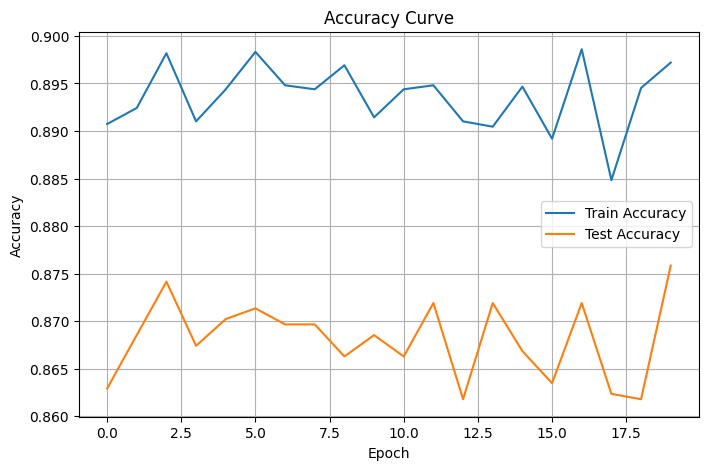

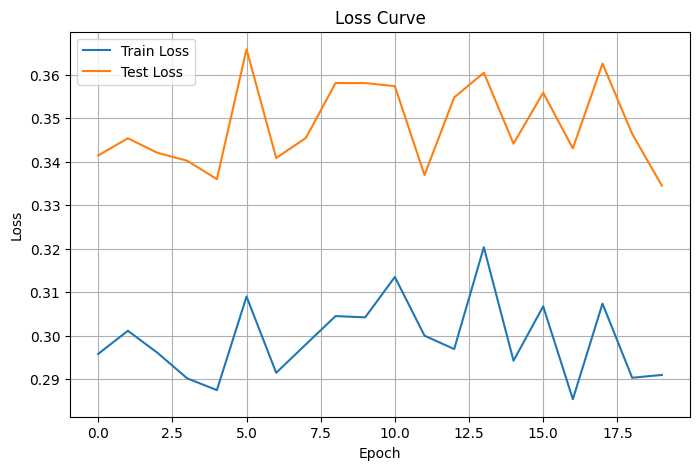

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    log_loss
)

# =========================
# LOAD DATA
# =========================

df = pd.read_csv("/kaggle/input/datasets/souptik22fiitbs/final-dataset/respiratory_disease_harder_nan_target93_8900.csv")

X = df["Clinical_Observation"]
y = df["Diagnosis_Label"]

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# TF-IDF
# =========================

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# =========================
# LOGISTIC REGRESSION
# =========================

model = LogisticRegression(
    solver='saga',
    max_iter=1,
    warm_start=True
)

# =========================
# TRAINING LOOP
# =========================

epochs = 20

train_accs = []
test_accs  = []

train_losses = []
test_losses  = []

for epoch in range(epochs):

    model.fit(X_train_tfidf, y_train)

    # Predictions
    train_preds = model.predict(X_train_tfidf)
    test_preds  = model.predict(X_test_tfidf)

    # Probabilities
    train_probs = model.predict_proba(X_train_tfidf)
    test_probs  = model.predict_proba(X_test_tfidf)

    # Accuracy
    train_acc = accuracy_score(y_train, train_preds)
    test_acc  = accuracy_score(y_test, test_preds)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Loss
    train_loss = log_loss(y_train, train_probs)
    test_loss  = log_loss(y_test, test_probs)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

# =========================
# FINAL EVALUATION
# =========================

y_pred = model.predict(X_test_tfidf)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

# =========================
# SPECIFICITY
# =========================

cm = confusion_matrix(y_test, y_pred)

specificities = []

for i in range(len(cm)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificities.append(specificity)

overall_specificity = np.mean(specificities)

# =========================
# PRINT RESULTS
# =========================

print(f"\nAccuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"Specificity  : {overall_specificity:.4f}\n")

print(classification_report(y_test, y_pred))

# =========================
# PLOT ACCURACY
# =========================

plt.figure(figsize=(8,5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(test_accs, label='Test Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# PLOT LOSS
# =========================

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()